In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
!pip install datasets

In [5]:
from datasets import load_dataset

dataset = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [7]:
from datasets import load_dataset

dataset = load_dataset("imdb")

In [10]:
df = pd.concat([train_df, test_df], ignore_index=True)

In [11]:
import pandas as pd

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

In [15]:
df.head()

,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [13]:
df.shape

(50000, 2)

In [14]:
df = df.rename(columns={
    "text": "review",
    "label": "sentiment"
})

In [16]:
df["sentiment"].value_counts()

,count
sentiment,
0,25000
1,25000


In [18]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)          # حذف HTML
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # حذف اعداد و علائم
    text = re.sub(r"\s+", " ", text).strip()    # حذف فاصله‌های اضافی
    return text

In [19]:
df["clean_review"] = df["review"].apply(clean_text)

In [20]:
df[["review", "clean_review"]].head(3)

,review,clean_review
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...


In [21]:
X = df["clean_review"]
y = df["sentiment"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000,), (10000,), (40000,), (10000,))

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

In [25]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [26]:
X_train_tfidf.shape, X_test_tfidf.shape

((40000, 10000), (10000, 10000))

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [28]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [29]:
y_pred = model.predict(X_test_tfidf)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.897


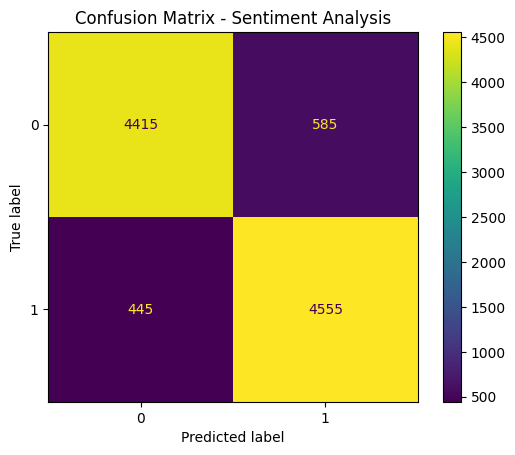

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

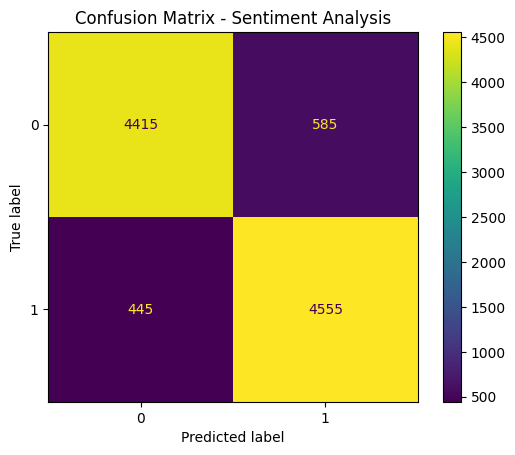

In [32]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Sentiment Analysis")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

In [33]:
import numpy as np
import pandas as pd

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

In [34]:
top_positive_idx = np.argsort(coefficients)[-15:]
top_positive_words = feature_names[top_positive_idx]
top_positive_scores = coefficients[top_positive_idx]

positive_df = pd.DataFrame({
    "word": top_positive_words,
    "score": top_positive_scores
}).sort_values(by="score", ascending=False)

positive_df

,word,score
14,great,7.238026
13,excellent,6.689533
12,perfect,5.655520
11,best,5.637586
10,wonderful,5.161367
9,amazing,5.140009
8,favorite,4.668435
7,brilliant,4.661500
6,hilarious,4.523622
5,today,4.408240


In [35]:
top_negative_idx = np.argsort(coefficients)[:15]
top_negative_words = feature_names[top_negative_idx]
top_negative_scores = coefficients[top_negative_idx]

negative_df = pd.DataFrame({
    "word": top_negative_words,
    "score": top_negative_scores
}).sort_values(by="score", ascending=True)

negative_df

,word,score
0,worst,-9.557381
1,awful,-7.903620
2,bad,-7.247896
3,boring,-6.721045
4,waste,-6.660386
5,poor,-6.167510
6,terrible,-6.027465
7,worse,-5.252782
8,disappointment,-5.200641
9,horrible,-5.142437


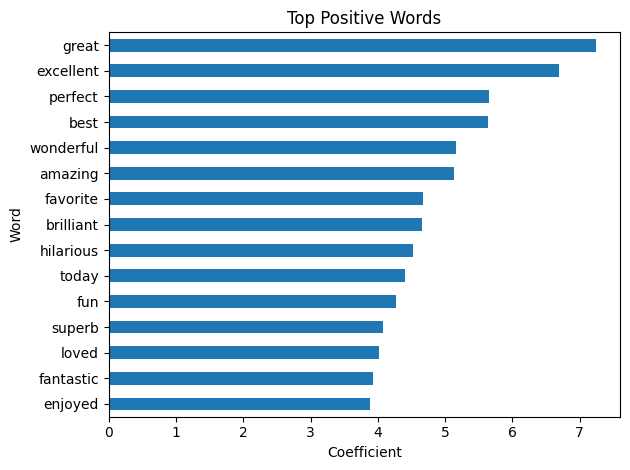

In [36]:
positive_df.sort_values(by="score", ascending=True).plot(
    x="word",
    y="score",
    kind="barh",
    legend=False
)
plt.title("Top Positive Words")
plt.xlabel("Coefficient")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("top_positive_words.png", bbox_inches="tight")
plt.show()

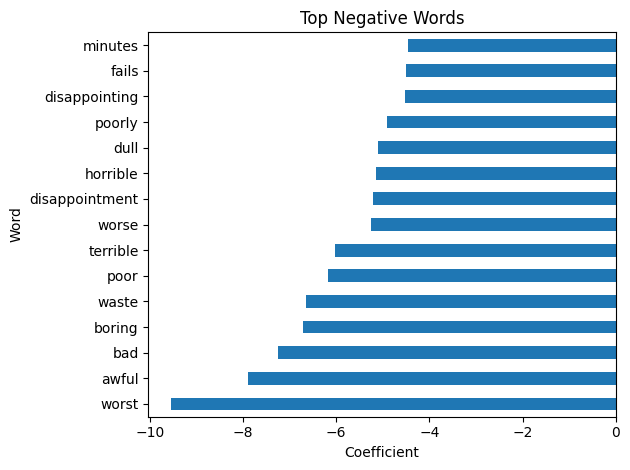

In [37]:
negative_df.sort_values(by="score", ascending=True).plot(
    x="word",
    y="score",
    kind="barh",
    legend=False
)
plt.title("Top Negative Words")
plt.xlabel("Coefficient")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("top_negative_words.png", bbox_inches="tight")
plt.show()

In [38]:
sample_reviews = [
    "This movie was fantastic, emotional, and beautifully directed.",
    "The plot was boring and the acting was terrible."
]

In [39]:
sample_reviews_clean = [clean_text(r) for r in sample_reviews]
sample_reviews_tfidf = vectorizer.transform(sample_reviews_clean)
sample_preds = model.predict(sample_reviews_tfidf)
sample_probs = model.predict_proba(sample_reviews_tfidf)

In [40]:
for review, pred, prob in zip(sample_reviews, sample_preds, sample_probs):
    label = "positive" if pred == 1 else "negative"
    print("Review:", review)
    print("Predicted sentiment:", label)
    print("Probabilities:", prob)
    print("-" * 50)

Review: This movie was fantastic, emotional, and beautifully directed.
Predicted sentiment: positive
Probabilities: [0.01919469 0.98080531]
--------------------------------------------------
Review: The plot was boring and the acting was terrible.
Predicted sentiment: negative
Probabilities: [0.99889657 0.00110343]
--------------------------------------------------


In [41]:
accuracy

0.897

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90      5000
           1       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [43]:
positive_df.head(10)

,word,score
14,great,7.238026
13,excellent,6.689533
12,perfect,5.655520
11,best,5.637586
10,wonderful,5.161367
9,amazing,5.140009
8,favorite,4.668435
7,brilliant,4.661500
6,hilarious,4.523622
5,today,4.408240


In [44]:
negative_df.head(10)

,word,score
0,worst,-9.557381
1,awful,-7.903620
2,bad,-7.247896
3,boring,-6.721045
4,waste,-6.660386
5,poor,-6.167510
6,terrible,-6.027465
7,worse,-5.252782
8,disappointment,-5.200641
9,horrible,-5.142437


In [46]:
content = """
# Business Insights from Sentiment Analysis

1. Sentiment analysis can automatically classify customer feedback.

2. Positive reviews often highlight product quality and enjoyment.

3. Negative reviews frequently mention poor experience or dissatisfaction.

4. Sentiment monitoring helps detect problems early.

5. Customer feedback can guide product improvements.
"""

with open("business_insights.md", "w") as f:
    f.write(content)

print("business_insights.md created")

business_insights.md created
